# **GeneratorV2 Inference Scrip**

This script performs inference using the **GeneratorV2** model to transform live-action images into cartoon-style images. It loads the first N images from a folder, applies the generator, and visualizes the results in a grid layout.

## Key Features

### Generator Setup
- Loads a **GeneratorV2** model in evaluation mode (`eval`) on CPU or GPU.  
- Generator weights are provided via a `.pt` file.  

### Image Preprocessing
- Reads images using OpenCV and converts BGR to RGB.  
- Resizes images to the model’s expected input size (default 256×256).  
- Normalizes pixel values to the [-1, 1] range for model input.

### Inference
- Passes each image through the generator to produce cartoonized outputs.  
- Converts the output tensor back to standard image format [0, 255].

### Visualization
- Displays the first N predicted images in a configurable grid (default 3x5).

## Usage
1. Set `folder_path` to the directory containing your test images.  
2. Provide the path to your pre-trained generator weights (`.pt`).  
3. Adjust `num_images`, `grid_rows`, and `grid_cols`.

In [ ]:
!git clone https://github.com/denisevaldivia/Disney_GAN.git
import os
os.chdir('Disney_GAN')

Cloning into 'Disney_GAN'...
remote: Enumerating objects: 105, done.
remote: Total 105 (delta 0), reused 0 (delta 0), pack-reused 105 (from 1)
Receiving objects: 100% (105/105), 159.66 MiB | 15.87 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Updating files: 100% (26/26), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append("/content/Disney_GAN")

In [ ]:
import zipfile

# We extract our images from Drive
zip_path = "/content/drive/MyDrive/GAN/dataset_GAN_smooth.zip"
extract_path = "/content/dataset_gan"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted
Dataset extracted


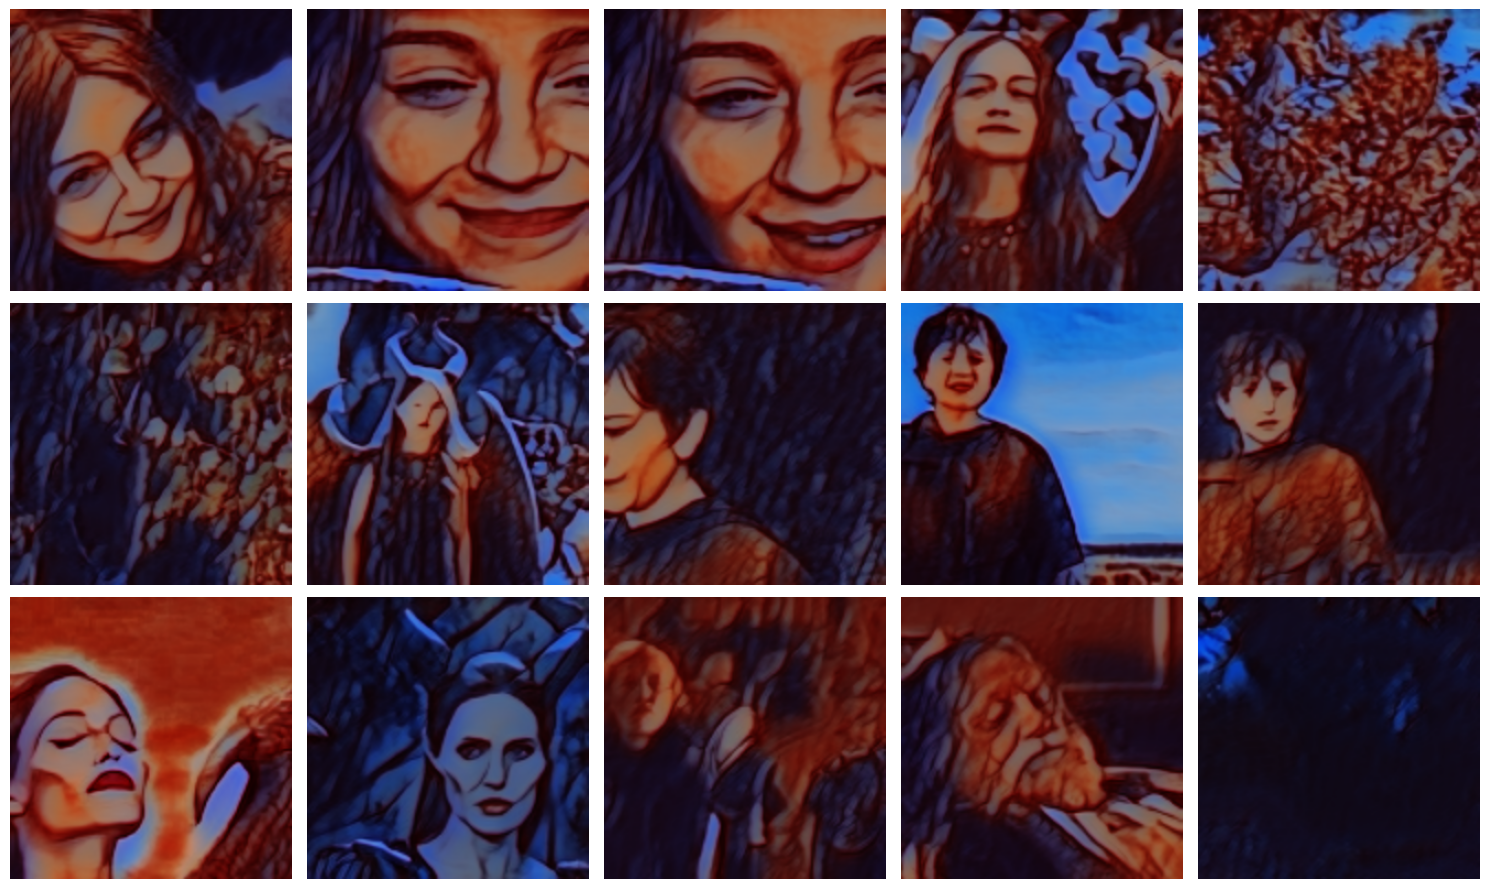

In [12]:
import os
import cv2
import torch
from src.models.AnimeGANv2_Generator import GeneratorV2
import matplotlib.pyplot as plt

# Global variables
folder_path = "/content/dataset_gan/test/live_action"
start = 0
num_images = 15 # Num images for testing
grid_rows, grid_cols = 3,5
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load weights
map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint = torch.load("/content/Disney_GAN/src/Weights/GeneratorV2_live_action_cartoon_meh.pt", map_location=map_location)

# handle case if checkpoint is a dict containing model_state_dict
if "model_state_dict" in checkpoint:
  state_dict = checkpoint["model_state_dict"]
else:
  state_dict = checkpoint

# Create class object Generator
net_g = GeneratorV2().to(device)
new_state_dict = {k[len("module."):] if k.startswith("module.") else k: v for k, v in state_dict.items()}
net_g.load_state_dict(new_state_dict, strict=True)

# Set to eval
net_g.eval()

# Function helpers to normalize images
def preprocess_image(path, size=(256,256)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    tensor = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0)
    tensor = (tensor / 127.5) - 1.0
    return tensor.to(device)

def postprocess_tensor(tensor):
    img = ((tensor.squeeze(0).permute(1,2,0)+1)*127.5).clamp(0,255).byte().cpu().numpy()
    return img

# Select images
image_files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path)
                     if f.lower().endswith(('.png','.jpg','.jpeg'))])[start:start+num_images]

# Run inference
pred_images = []
for path in image_files:
    with torch.no_grad():
        input_tensor = preprocess_image(path)
        output_tensor = net_g(input_tensor)
        pred_images.append(postprocess_tensor(output_tensor))

# Plot grid
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15,9))
axes = axes.flatten()
for ax,img in zip(axes,pred_images):
    ax.imshow(img)
    ax.axis("off")
for ax in axes[len(pred_images):]:
    ax.axis("off")
plt.tight_layout()
plt.show()